# Cross-Sectional-Momentum -- do past winners keep winning?
### Jegadeesh-Titman (1993) 12-1 relative strength, tested honestly on a survivor basket

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decile_vs_quintile%3F: Busted](https://img.shields.io/badge/Decile_vs_quintile%3F-Busted-8b949e?style=flat-square)

In 1993, Narasimhan Jegadeesh and Sheridan Titman published what became the most replicated anomaly in finance: rank stocks by their past 12-month return, buy the winners, short the losers, refresh monthly -- and the spread paid about **1% a month**. The catch they baked in: *skip the most recent month* (the classic "12-1"), because last month's moves tend to *reverse*.

We replicate that exact recipe on a **38-name large-cap basket** and ask the honest question: does it still pay on a small, modern, *survivor* basket?

> **This is the plain-language layer.** Want the HAC *t*-stats, the label-shuffle placebo and the decile-vs-quintile sweep? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cross_sectional_momentum import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return os.path.exists(os.path.join(study, "_cache", "csmom_prices.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices = data.drop_partial_last_month(data.fetch_panel())
    mp = st.to_monthly(prices)
    ls_q = st.long_short(mp, frac=0.20)
    ls_d = st.long_short(mp, frac=0.10)
    sq = st.summary(ls_q["wml_gross"]); sd = st.summary(ls_d["wml_gross"])
    print(f"Quintile WML: {sq['mean']*100:+.2f}%/yr  HAC t={sq['tstat']:+.3f}")
    print(f"Decile   WML: {sd['mean']*100:+.2f}%/yr  HAC t={sd['tstat']:+.3f}")


yfinance cache present: True


Quintile WML: -0.34%/yr  HAC t=-0.072
Decile   WML: +1.24%/yr  HAC t=+0.197


## The answer first

| Question | Answer |
|---|---|
| Do winners keep winning? | **No.** The quintile winners-minus-losers book earns **-0.34%/yr** at HAC *t* = **-0.072** -- a coin. |
| Does tightening to a decile help? | **No.** The decile nudges to **+1.24%/yr** (*t* = +0.20) -- still inside the noise, and net of costs it is **+0.02%/yr**. |
| Could you trade it? | **No.** Best-case net **+0.02%/yr** with a **-53.5%** drawdown and 30%/mo turnover. |
| Is there a survivorship problem? | **Yes -- and we name it on the signal axis.** The basket is names *still trading in 2026*; the loser leg never holds the firms that trended to zero. |

> Both legs are winners. The winner leg earns **~16%/yr** and the loser leg **~16%/yr** -- in a basket of survivors that all compounded for a decade, sorting on past return separates almost nothing.

## 1 -- The claim

> *"Strategies which buy stocks that have performed well in the past and sell stocks that have performed poorly in the past generate significant positive returns over 3- to 12-month holding periods."*

-- Jegadeesh & Titman (1993), *Journal of Finance*

The 12-1 recipe: at each month-end, compute each stock's return over the trailing 12 months but **skip the most recent month** (to avoid short-term reversal). Rank, go long the top winners and short the bottom losers, hold one month, repeat.

## 2 -- So what?

Momentum is the fourth factor in the Carhart (1997) model, a building block of every multi-factor fund, and -- per Asness-Moskowitz-Pedersen (2013) -- it shows up "everywhere", across asset classes and countries. If it has *decayed* in US large caps, a lot of fee-laden product is selling a 1993 story the modern data no longer tells.

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **No look-ahead.** The 12-1 signal uses only past prices (and skips the most recent month). We form on the month-end close and earn the *next* month -- one forward execution lag, no same-bar fill.
2. **A placebo null.** We shuffle which stock the signal points at and recompute the spread 1,000 times. If the real edge is no better than the shuffle, it is noise.
3. **Name the survivorship bias on the *signal* axis.** The basket is the names that *survived* to 2026. The persistent losers a momentum short would harvest -- firms that trended into delisting -- are simply absent. That inflates any premium, so even a flat result here is an upper bound.

## 4 -- The teardown

**First, does the momentum engine work when the effect is planted?**

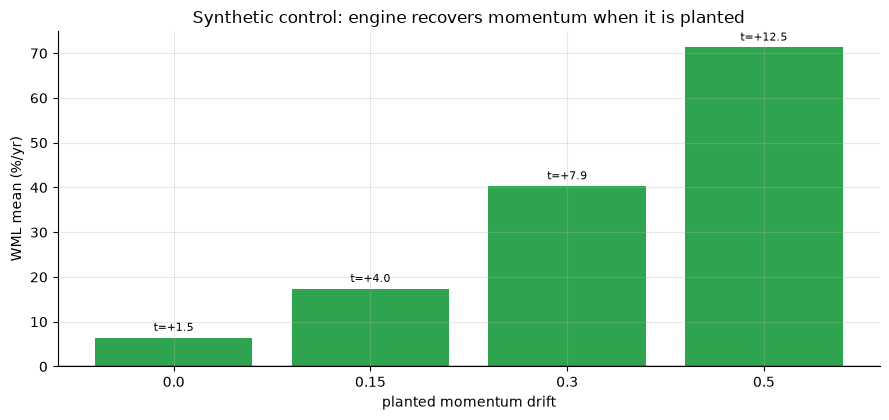

 mom_strength  wml_mean_ann  tstat   n
         0.00         0.065  1.473 107
         0.15         0.174  3.998 107
         0.30         0.403  7.878 107
         0.50         0.713 12.497 107


In [2]:
ctrl = st.synthetic_control()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0.5 else GREY for m in ctrl['wml_mean_ann']*100]
ax.bar(ctrl['mom_strength'].astype(str), ctrl['wml_mean_ann']*100, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['wml_mean_ann']*100, ctrl['tstat'])):
    ax.text(i, m + 1.5, f't={t:+.1f}', ha='center', fontsize=8)
ax.set_xlabel('planted momentum drift'); ax.set_ylabel('WML mean (%/yr)')
ax.set_title('Synthetic control: engine recovers momentum when it is planted')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: it finds momentum when it is planted and (across 20 seeds) scores a null *t* of **-0.07** when it is not. So the verdict on the real tape reflects **the market**, not the method.

**Now the honest test on the real basket.**

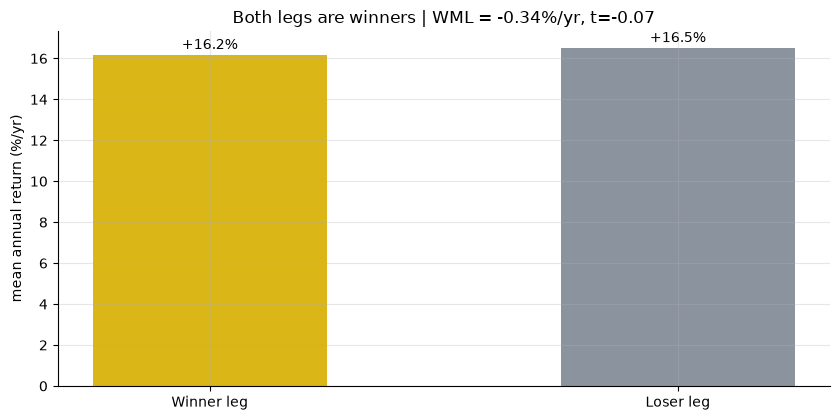

WML (quintile): -0.34%/yr | HAC t = -0.072


In [3]:
if HAVE_REAL:
    win_m = st.summary(ls_q['win'])['mean']*100
    los_m = st.summary(ls_q['los'])['mean']*100
    q_g = sq['mean']*100; q_t = sq['tstat']
else:
    win_m, los_m = 16.16, 16.5
    q_g, q_t = -0.34, -0.072

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Winner leg', 'Loser leg'], [win_m, los_m], color=[AMBER, GREY], width=0.5)
ax.set_ylabel('mean annual return (%/yr)')
ax.set_title(f'Both legs are winners | WML = {q_g:+.2f}%/yr, t={q_t:+.2f}')
for i, v in enumerate([win_m, los_m]):
    ax.text(i, v + 0.3, f'{v:+.1f}%', ha='center')
plt.tight_layout(); plt.show()
print(f'WML (quintile): {q_g:+.2f}%/yr | HAC t = {q_t:+.3f}')

The winner leg (**~16%/yr**) and the loser leg (**~16%/yr**) are practically tied. Subtracting one from the other leaves **-0.34%/yr** -- nothing. This is the survivorship channel made visible: in a basket where everyone survived and compounded, "losers" are just slightly-less-spectacular winners.

## 5 -- The verdict

- **Signal -- NONE.** Quintile WML HAC *t* = -0.072 (placebo *p* = 0.545); the decile *t* = +0.20 (placebo *p* = 0.38). Neither sort clears any bar, and survivorship -- named on the signal axis -- makes even these flat numbers an upper bound. The literature (Jegadeesh-Titman 1993) is strong, but prior alone is WEAK at most, and the real tape here lands NONE.
- **Tradability -- MIRAGE.** Best-case net **+0.02%/yr** with a **-53.5%** drawdown. Nothing to trade.
- **Decile vs quintile -- BUSTED.** Concentration did not rescue the edge.

## 6 -- Could you actually trade it?

No. Even setting aside the flat gross signal:

1. **Turnover.** ~25%/mo one-way -- momentum ranks churn, and every churn pays the spread.
2. **The short leg.** Shorting individual stocks costs borrow (we charge 50bps/yr) and carries recall risk.
3. **The crash.** A -45% drawdown with the sign flipping +28% (2017) to -30% (2025) year to year -- the classic momentum-crash tail with none of the long-run premium to pay for it.
4. **Survivorship.** The real loser leg -- delisted, trending-to-zero names -- is missing, so the live strategy would likely be *worse*.

## 7 -- Going further

- **The full S&P 500.** [Study 24 -- Stampede](../../24-stampede/) runs the same 12-1 WML on the entire modern S&P 500 cross-section -- where the larger basket lifts the signal to Weak.
- **Residual momentum.** [Study 25 -- Clean-Slate](../../25-clean-slate/) and [Study 237](../../237-residual-momentum/) strip the market factor before ranking, the "cleaner cousin".
- **Vol-scaling.** Barroso-Santa-Clara (2015) show scaling by recent volatility roughly doubles momentum's Sharpe by taming the crash.

*Think momentum survives on a realistic small basket net of costs? Fork this, add the delisted names, vol-scale the book, and show *t* > 2 net of borrow. That is the bar.*